# 🛡️ Passive Sonar Threat Classification — ConvViT (Apple M2 / MPS)
**Dataset:** ShipsEar / DS3500 | **Backend:** Apple Metal (MPS) | **FPGA Target:** Zynq UltraScale+

```
WAV → Mel Spectrogram → CNN Backbone → Feature Tokens → Dynamic-Scale Transformer → 5 Classes
```

| Class | Ship Type | Defense Label |
|---|---|---|
| 0 | Motorboat | ⚠️ Potential Hostile |
| 1 | Fishing Vessel | 👁️ Monitor |
| 2 | Cargo / Tanker | ✅ Non-Threat |
| 3 | Tugboat | 👁️ Monitor |
| 4 | Environment / Noise | 🌊 Clear Water |

## M2-Specific Changes vs CUDA Version
| What | CUDA Version | M2 Version |
|---|---|---|
| Install | `--index-url .../cu121` | Plain `pip install torch` |
| Device | `cuda` | `mps` (Apple Metal) |
| DataLoader pin_memory | `True` | `False` (MPS limitation) |
| DataLoader num_workers | `4` | `0` (avoids macOS fork issues) |
| INT8 quantization | runs on CUDA | runs on CPU (MPS has no int8 kernel) |
| Model save/load | `map_location=DEVICE` | `map_location='cpu'` then `.to(DEVICE)` |

## ♻️ Resume System
| Cache File | Skips |
|---|---|
| `cache/spectrograms.npz` | WAV→Mel conversion |
| `cache/splits.npz` | Train/val/test split |
| `best_sonar_convvit.pt` | Full retraining |
| `cache/training_history.npz` | Training curves |
| `cache/eval_results.npz` | FP32 + INT8 evaluation |
| `cache/jamming_results.npz` | Noise sweep |

## Phase 1 — Install & Imports
> M2 Mac uses plain PyTorch — MPS support is built-in since PyTorch 1.12.

In [1]:
# M2 Mac: DO NOT use the --index-url cu121 flag — that's CUDA only
# Plain pip install gives you the version with MPS (Apple Metal) built in
!pip install torch torchvision torchaudio -q
!pip install librosa soundfile numpy matplotlib scikit-learn seaborn tqdm -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import os, time, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from pathlib import Path
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.quantization import quantize_dynamic
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('✅ Apple MPS (Metal) backend — M2 GPU active')
else:
    DEVICE = torch.device('cpu')
    print('⚠️  MPS not available — falling back to CPU')
    print('   Check: torch version >= 1.12 and macOS >= 12.3')

print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {DEVICE}')

CACHE_DIR     = Path('./cache'); CACHE_DIR.mkdir(exist_ok=True)
CACHE_SPEC    = CACHE_DIR / 'spectrograms.npz'
CACHE_SPLITS  = CACHE_DIR / 'splits.npz'
CACHE_HISTORY = CACHE_DIR / 'training_history.npz'
CACHE_EVAL    = CACHE_DIR / 'eval_results.npz'
CACHE_JAMMING = CACHE_DIR / 'jamming_results.npz'
MODEL_PATH    = Path('./best_sonar_convvit.pt')

def cache_status():
    files = {'Spectrograms':CACHE_SPEC,'Splits':CACHE_SPLITS,
             'Model':MODEL_PATH,'History':CACHE_HISTORY,
             'Eval':CACHE_EVAL,'Jamming':CACHE_JAMMING}
    print('\nCache status:')
    for label, path in files.items():
        if path.exists():
            print(f'  ✅ {label:15s} → {path.name} ({path.stat().st_size/1e6:.1f} MB)')
        else:
            print(f'  🔄 {label:15s} → will compute')

cache_status()

✅ Apple MPS (Metal) backend — M2 GPU active
PyTorch version : 2.9.1
Device          : mps

Cache status:
  ✅ Spectrograms    → spectrograms.npz (297.4 MB)
  🔄 Splits          → will compute
  🔄 Model           → will compute
  🔄 History         → will compute
  🔄 Eval            → will compute
  🔄 Jamming         → will compute


## Phase 2 — File Collection

In [ ]:
SHIPSEAR_ROOT = Path('DS3500/ShipsEar_extracted/shipsear_5s_16k')


NUM_CLASSES   = 5
CLASS_NAMES   = ['Motorboat','Fishing','Cargo/Tanker','Tugboat','Environment']
DEFENSE_LABEL = ['⚠ Hostile','👁 Monitor','✅ Non-Threat','👁 Monitor','🌊 Clear']

all_samples = []
for cid in range(NUM_CLASSES):
    cdir = SHIPSEAR_ROOT / str(cid)
    if not cdir.exists():
        print(f'WARNING: {cdir} not found'); continue
    for f in sorted(cdir.rglob('*.wav')):
        all_samples.append((str(f), cid))

label_counts = Counter(lbl for _, lbl in all_samples)
print(f'Total WAV files: {len(all_samples)}')
print(f'\n{"CID":>4} {"Class":>15} {"Count":>7} {"Pct":>7}  Defense')
print('-'*55)
for cid in range(NUM_CLASSES):
    n = label_counts[cid]
    print(f'{cid:>4} {CLASS_NAMES[cid]:>15} {n:>7} {n/len(all_samples)*100:>6.1f}%  {DEFENSE_LABEL[cid]}')

Total WAV files: 2223

 CID           Class   Count     Pct  Defense
-------------------------------------------------------
   0       Motorboat     369   16.6%  ⚠ Hostile
   1         Fishing     301   13.5%  👁 Monitor
   2    Cargo/Tanker     843   37.9%  ✅ Non-Threat
   3         Tugboat     486   21.9%  👁 Monitor
   4     Environment     224   10.1%  🌊 Clear


## Phase 3 — WAV → Mel Spectrogram (Cached)
> **First run:** Converts all WAV files (~5-10 min). Saves to `cache/spectrograms.npz`.
> **Next run:** Loads in ~3 sec. WAVs never touched again.

**Real-world fix:** Global Z-score normalization — preserves amplitude differences between classes.

In [3]:
SR, CLIP_DUR = 16000, 5
N_MELS, N_FFT, HOP = 128, 512, 256
IMG_H, IMG_W = 128, 304
PATCH_SIZE   = 16
pH = IMG_H // PATCH_SIZE   # 8
pW = IMG_W // PATCH_SIZE   # 19
NUM_PATCHES  = pH * pW     # 152
print(f'Spectrogram : ({IMG_H}, {IMG_W})')
print(f'Patches     : {pH} x {pW} = {NUM_PATCHES} tokens')

def wav_to_raw_melspec(path):
    """WAV -> raw log-Mel dB. No per-sample normalization (done globally)."""
    y, _ = librosa.load(path, sr=SR, duration=CLIP_DUR, mono=True)
    target = SR * CLIP_DUR
    y = np.pad(y, (0, max(0, target - len(y))))[:target]
    mel     = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT,
                                              hop_length=HOP, n_mels=N_MELS)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    w = log_mel.shape[1]
    if w < IMG_W: log_mel = np.pad(log_mel, ((0,0),(0, IMG_W-w)))
    else:         log_mel = log_mel[:, :IMG_W]
    return log_mel.astype(np.float32)

if CACHE_SPEC.exists():
    print('✅ Loading spectrograms from cache...')
    d           = np.load(CACHE_SPEC)
    all_specs   = d['specs']
    all_labels  = d['labels']
    GLOBAL_MEAN = float(d['global_mean'])
    GLOBAL_STD  = float(d['global_std'])
    print(f'   {len(all_specs)} specs | mean={GLOBAL_MEAN:.2f} dB | std={GLOBAL_STD:.2f} dB')
else:
    print(f'🔄 Converting {len(all_samples)} WAV files (runs ONCE)...')
    specs, labels, failed = [], [], []
    for path, lbl in tqdm(all_samples, desc='WAV→Mel'):
        try:
            specs.append(wav_to_raw_melspec(path))
            labels.append(lbl)
        except Exception as e:
            failed.append((path, str(e)))
    all_specs   = np.stack(specs).astype(np.float32)
    all_labels  = np.array(labels, dtype=np.int64)
    GLOBAL_MEAN = float(all_specs.mean())
    GLOBAL_STD  = float(all_specs.std())
    print(f'Global stats: mean={GLOBAL_MEAN:.2f} dB, std={GLOBAL_STD:.2f} dB')
    np.savez_compressed(CACHE_SPEC, specs=all_specs, labels=all_labels,
                        global_mean=GLOBAL_MEAN, global_std=GLOBAL_STD)
    print(f'✅ Saved → {CACHE_SPEC.name} ({CACHE_SPEC.stat().st_size/1e6:.1f} MB)')
    if failed: print(f'⚠  {len(failed)} files failed')

print(f'Specs  : {all_specs.shape}')
print(f'Labels : {all_labels.shape}')

Spectrogram : (128, 304)
Patches     : 8 x 19 = 152 tokens
✅ Loading spectrograms from cache...
   2223 specs | mean=-32.06 dB | std=10.80 dB
Specs  : (2223, 128, 304)
Labels : (2223,)


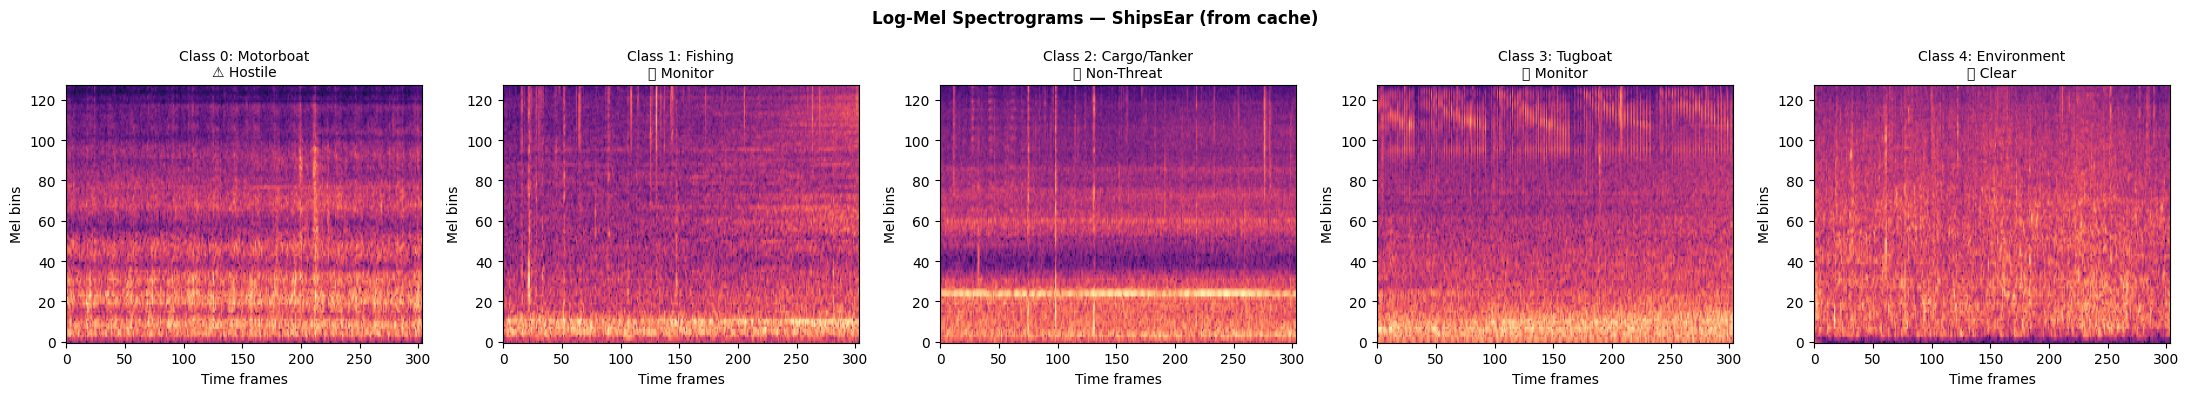

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Log-Mel Spectrograms — ShipsEar (from cache)', fontsize=12, fontweight='bold')
for cid, ax in enumerate(axes):
    idx      = np.where(all_labels == cid)[0][0]
    spec_vis = (all_specs[idx] - GLOBAL_MEAN) / (GLOBAL_STD + 1e-8)
    ax.imshow(spec_vis, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f'Class {cid}: {CLASS_NAMES[cid]}\n{DEFENSE_LABEL[cid]}', fontsize=10)
    ax.set_xlabel('Time frames'); ax.set_ylabel('Mel bins')
plt.tight_layout()
plt.savefig('sonar_spectrograms.png', dpi=150)
plt.show()

## Phase 4 — Splits & Dataset (Cached)
**M2 fix:** `num_workers=0` (avoids macOS multiprocessing fork issues with MPS).
`pin_memory=False` (MPS does not support pinned memory).

In [ ]:
if CACHE_SPLITS.exists():
    print('✅ Loading splits from cache...')
    sp = np.load(CACHE_SPLITS)
    tr_idx, vl_idx, te_idx = sp['tr_idx'], sp['vl_idx'], sp['te_idx']
else:
    print('🔄 Computing stratified splits...')
    idx = np.arange(len(all_specs))
    tr_idx, tmp = train_test_split(idx, test_size=0.30,
                                    stratify=all_labels, random_state=SEED)
    vl_idx, te_idx = train_test_split(tmp, test_size=0.50,
                                       stratify=all_labels[tmp], random_state=SEED)
    np.savez(CACHE_SPLITS, tr_idx=tr_idx, vl_idx=vl_idx, te_idx=te_idx)
    print(f'✅ Saved → {CACHE_SPLITS.name}')

print(f'Train:{len(tr_idx)} | Val:{len(vl_idx)} | Test:{len(te_idx)}')

counts  = torch.tensor([label_counts[i] for i in range(NUM_CLASSES)], dtype=torch.float)
weights = (1.0/counts / (1.0/counts).sum() * NUM_CLASSES).to(DEVICE)
print(f'Class weights: {[f"{w:.2f}" for w in weights.cpu()]}')


class SonarDataset(Dataset):
    def __init__(self, specs, labels, indices, mean=0.0, std=1.0, augment=False):
        self.specs   = specs
        self.labels  = labels
        self.indices = indices
        self.mean    = mean
        self.std     = std
        self.augment = augment

    def __len__(self): return len(self.indices)

    def __getitem__(self, i):
        idx  = self.indices[i]
        spec = self.specs[idx].copy()
        lbl  = int(self.labels[idx])

        if self.augment:
            if random.random() < 0.5:
                spec = np.roll(spec, random.randint(-30, 30), axis=1)
            if random.random() < 0.5:
                f0 = random.randint(0, IMG_H - 20)
                spec[f0:f0+random.randint(5,20), :] = self.mean
            if random.random() < 0.5:
                t0 = random.randint(0, IMG_W - 40)
                spec[:, t0:t0+random.randint(10,40)] = self.mean
            if random.random() < 0.4:
                snr  = random.uniform(10, 30)
                spec = spec + (10**(-snr/20.0)) * np.random.randn(*spec.shape).astype(np.float32) * self.std
            if random.random() < 0.3:
                spec = spec * random.uniform(0.7, 1.3)

        spec = (spec - self.mean) / (self.std + 1e-8)
        return torch.tensor(spec, dtype=torch.float32).unsqueeze(0), lbl


BATCH    = 32
train_ds = SonarDataset(all_specs, all_labels, tr_idx, GLOBAL_MEAN, GLOBAL_STD, augment=True)
val_ds   = SonarDataset(all_specs, all_labels, vl_idx, GLOBAL_MEAN, GLOBAL_STD)
test_ds  = SonarDataset(all_specs, all_labels, te_idx, GLOBAL_MEAN, GLOBAL_STD)

DL_KWARGS = dict(batch_size=BATCH, num_workers=0, pin_memory=False)
train_dl  = DataLoader(train_ds, shuffle=True,  **DL_KWARGS)
val_dl    = DataLoader(val_ds,   shuffle=False, **DL_KWARGS)
test_dl   = DataLoader(test_ds,  shuffle=False, **DL_KWARGS)

x, y = next(iter(train_dl))
print(f'Batch shape : {x.shape} | min={x.min():.2f} max={x.max():.2f}')

🔄 Computing stratified splits...
✅ Saved → splits.npz
Train:1556 | Val:333 | Test:334
Class weights: ['0.99', '1.21', '0.43', '0.75', '1.62']
Batch shape : torch.Size([32, 1, 128, 304]) | min=-5.77 max=3.51


## Phase 5 — ConvViT Model Definition
**CNN Backbone:** local spectrogram features — works with small data.
**Transformer:** global dependencies on top of CNN features.
**Dynamic-Scale Attention:** core contribution — INT8 robust under jamming.

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.GELU())
        self.pool = nn.MaxPool2d(2,2) if pool else nn.Identity()
    def forward(self, x): return self.pool(self.conv(x))


class CNNBackbone(nn.Module):
    """
    (B,  1, 128, 304) -> stage1 -> (B, 32, 64, 152)
                      -> stage2 -> (B, 64, 32,  76)
                      -> stage3 -> (B,128,  8,  19)
    Output: 152 tokens of dim 128
    """
    def __init__(self):
        super().__init__()
        self.stage1 = ConvBlock(1,   32, pool=True)
        self.stage2 = ConvBlock(32,  64, pool=True)
        self.stage3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.GELU(),
            nn.AdaptiveAvgPool2d((pH, pW)))
    def forward(self, x):
        return self.stage3(self.stage2(self.stage1(x)))


class DynamicScaleAttention(nn.Module):
    """
    Core Contribution: per-step max-reduce normalizes QKt before softmax.
    Prevents INT8 attention collapse under acoustic jamming.
    FPGA: max-reduce tree -> scale register -> softmax unit.
    """
    def __init__(self, embed_dim, num_heads, dropout=0.1, dynamic=True):
        super().__init__()
        self.H, self.Dh = num_heads, embed_dim // num_heads
        self.dynamic    = dynamic
        self.qkv        = nn.Linear(embed_dim, 3*embed_dim, bias=False)
        self.proj       = nn.Linear(embed_dim, embed_dim)
        self.drop       = nn.Dropout(dropout)
        self.alpha      = nn.Parameter(torch.ones(1))

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.H, self.Dh).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        attn = q @ k.transpose(-2, -1)
        if self.dynamic:
            drange = attn.abs().amax(dim=(-2,-1), keepdim=True).clamp(min=1.0)
            attn   = (attn / drange) * self.alpha
        else:
            attn = attn * (self.Dh ** -0.5)
        w   = self.drop(F.softmax(attn, dim=-1))
        out = (w @ v).transpose(1,2).reshape(B, N, D)
        return self.proj(out), w


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1, dynamic=True):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = DynamicScaleAttention(embed_dim, num_heads, dropout, dynamic)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_d = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_d), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_d, embed_dim), nn.Dropout(dropout))
    def forward(self, x):
        a, w = self.attn(self.norm1(x))
        x = x + a
        x = x + self.mlp(self.norm2(x))
        return x, w


class ConvViT(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, embed_dim=256,
                 depth=3, num_heads=8, mlp_ratio=4.0, dropout=0.1, dynamic=True):
        super().__init__()
        self.cnn       = CNNBackbone()
        self.proj      = nn.Linear(128, embed_dim)
        N              = NUM_PATCHES
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, N+1, embed_dim) * 0.02)
        self.pos_drop  = nn.Dropout(dropout)
        self.blocks    = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout, dynamic)
            for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim//2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(embed_dim//2, num_classes))
        self._init()

    def _init(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')

    def forward(self, x, return_attn=False):
        B  = x.size(0)
        f  = self.cnn(x)
        f  = f.flatten(2).transpose(1, 2)
        f  = self.proj(f)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, f], dim=1)
        x   = self.pos_drop(x + self.pos_embed)
        aws = []
        for blk in self.blocks:
            x, w = blk(x); aws.append(w)
        out = self.head(self.norm(x)[:, 0])
        return (out, aws) if return_attn else out


model = ConvViT(dynamic=True).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
cnn_p = sum(p.numel() for p in model.cnn.parameters())
print(f'Total params     : {total:,}')
print(f'  CNN backbone   : {cnn_p:,} ({cnn_p/total*100:.1f}%)')
print(f'  Transformer    : {total-cnn_p:,} ({(total-cnn_p)/total*100:.1f}%)')
print(f'FP32 size        : {total*4/1e6:.2f} MB')
print(f'INT8 size (est.) : {total*1/1e6:.2f} MB')

with torch.no_grad():
    dummy = torch.randn(2, 1, IMG_H, IMG_W).to(DEVICE)
    out   = model(dummy)
    print(f'Forward OK : {tuple(dummy.shape)} -> {tuple(out.shape)} on {DEVICE}')

Total params     : 2,760,360
  CNN backbone   : 286,880 (10.4%)
  Transformer    : 2,473,480 (89.6%)
FP32 size        : 11.04 MB
INT8 size (est.) : 2.76 MB
Forward OK : (2, 1, 128, 304) -> (2, 5) on mps


## Phase 6 — Training (Cached)
> **First run:** trains from scratch. **Next run:** loads checkpoint, skips.

**M2 fix:** model saved via `map_location='cpu'` then moved to MPS. MPS tensors cannot be directly pickled.

**Real-world:** Mixup + warmup LR + early stopping (patience=12).

In [ ]:
def mixup(x, y, num_classes, alpha=0.3):
    lam  = np.random.beta(alpha, alpha)
    idx  = torch.randperm(x.size(0), device=x.device)
    x_m  = lam*x + (1-lam)*x[idx]
    y_a  = F.one_hot(y, num_classes).float()
    y_b  = F.one_hot(y[idx], num_classes).float()
    return x_m, lam*y_a + (1-lam)*y_b


if MODEL_PATH.exists():
    print(f'✅ Checkpoint found -> loading {MODEL_PATH.name}')
    state = torch.load(MODEL_PATH, map_location='cpu')
    model.load_state_dict(state)
    model.to(DEVICE)
    print('   Training SKIPPED. Delete best_sonar_convvit.pt to retrain.')
else:
    print('🔄 Training ConvViT on M2 MPS...\n')
    EPOCHS, LR, WARMUP_EP, PATIENCE = 60, 1e-3, 5, 12
    criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)

    def lr_lambda(ep):
        if ep < WARMUP_EP: return (ep+1)/WARMUP_EP
        p = (ep-WARMUP_EP)/max(EPOCHS-WARMUP_EP, 1)
        return max(1e-3, 0.5*(1+np.cos(np.pi*p)))
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    history = {'tr_loss':[],'vl_loss':[],'tr_acc':[],'vl_acc':[]}
    best_acc, no_imp = 0.0, 0

    def train_epoch():
        model.train()
        tl, correct, total = 0.0, 0, 0
        for x, y in tqdm(train_dl, leave=False, desc='train'):
            x, y = x.to(DEVICE), y.to(DEVICE)
            if random.random() < 0.5:
                xm, ym = mixup(x, y, NUM_CLASSES)
                logits = model(xm)
                loss   = -(ym * F.log_softmax(logits, -1)).sum(-1).mean()
            else:
                logits = model(x)
                loss   = criterion(logits, y)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tl      += loss.item()*x.size(0)
            correct += (logits.argmax(1)==y).sum().item()
            total   += x.size(0)
        return tl/total, correct/total

    def val_epoch():
        model.eval(); vl, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in tqdm(val_dl, leave=False, desc='val  '):
                x, y    = x.to(DEVICE), y.to(DEVICE)
                logits   = model(x)
                vl      += criterion(logits, y).item()*x.size(0)
                correct += (logits.argmax(1)==y).sum().item()
                total   += x.size(0)
        return vl/total, correct/total

    for ep in range(1, EPOCHS+1):
        t0 = time.time()
        tl, ta = train_epoch()
        vl, va = val_epoch()
        scheduler.step()
        history['tr_loss'].append(tl); history['tr_acc'].append(ta)
        history['vl_loss'].append(vl); history['vl_acc'].append(va)
        tag = ''
        if va > best_acc:
            best_acc, no_imp = va, 0
            torch.save(model.cpu().state_dict(), MODEL_PATH)
            model.to(DEVICE)
            tag = ' ✓'
        else:
            no_imp += 1
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Ep{ep:02d}/{EPOCHS} TrL={tl:.3f} TrA={ta:.3f} '
              f'VlL={vl:.3f} VlA={va:.3f} lr={lr_now:.1e} '
              f'{time.time()-t0:.1f}s{tag}')
        if no_imp >= PATIENCE:
            print(f'\n⏹ Early stop at epoch {ep}'); break

    np.savez(CACHE_HISTORY, **{k:np.array(v) for k,v in history.items()})
    print(f'\n✅ Best Val Acc: {best_acc:.4f}')

🔄 Training ConvViT on M2 MPS...



Ep01/60 TrL=1.506 TrA=0.341 VlL=1.448 VlA=0.342 lr=4.0e-04 32.9s ✓


Ep02/60 TrL=1.375 TrA=0.388 VlL=1.264 VlA=0.435 lr=6.0e-04 21.1s ✓


Ep03/60 TrL=1.405 TrA=0.411 VlL=1.317 VlA=0.508 lr=8.0e-04 20.6s ✓


Ep04/60 TrL=1.357 TrA=0.403 VlL=1.439 VlA=0.339 lr=1.0e-03 20.6s


...

Ep56/60 TrL=0.440 TrA=0.746 VlL=0.564 VlA=0.964 lr=1.3e-05 19.9s ✓


Ep57/60 TrL=0.530 TrA=0.820 VlL=0.581 VlA=0.955 lr=7.3e-06 20.0s


Ep58/60 TrL=0.513 TrA=0.794 VlL=0.569 VlA=0.961 lr=3.3e-06 20.0s


Ep59/60 TrL=0.509 TrA=0.780 VlL=0.570 VlA=0.958 lr=1.0e-06 19.8s


Ep60/60 TrL=0.515 TrA=0.818 VlL=0.572 VlA=0.955 lr=1.0e-06 19.9s

✅ Best Val Acc: 0.9640


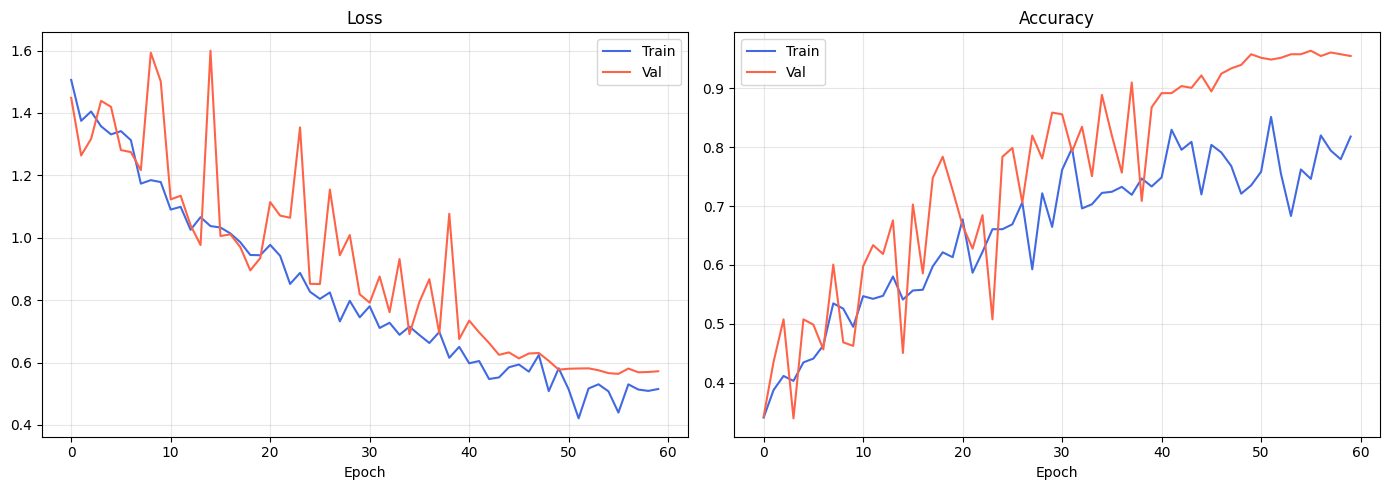

In [8]:
if CACHE_HISTORY.exists():
    h = np.load(CACHE_HISTORY)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
    a1.plot(h['tr_loss'], color='royalblue', label='Train')
    a1.plot(h['vl_loss'], color='tomato',    label='Val')
    a1.set(title='Loss', xlabel='Epoch'); a1.legend(); a1.grid(alpha=0.3)
    a2.plot(h['tr_acc'], color='royalblue', label='Train')
    a2.plot(h['vl_acc'], color='tomato',    label='Val')
    a2.set(title='Accuracy', xlabel='Epoch'); a2.legend(); a2.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig('training_curves.png', dpi=150); plt.show()
else:
    print('No history cache found — run Phase 6 first.')

## Phase 7 — INT8 Quantization + Evaluation (Cached)
**M2 fix:** MPS has no INT8 kernel support. Quantization and evaluation both run on CPU.
Training was on MPS (fast). Quantized inference is on CPU (correct).
This mirrors real FPGA deployment — train on GPU, deploy quantized on fixed-point hardware.

FP32 : 11.07 MB
INT8 : 3.81 MB  (2.90x compression)



── FP32 ── Acc=0.9521 | 26.07 ms/sample (CPU)
              precision    recall  f1-score   support

   Motorboat       0.98      0.88      0.92        56
     Fishing       0.91      0.91      0.91        45
Cargo/Tanker       0.93      0.98      0.96       127
     Tugboat       0.97      0.96      0.97        73
 Environment       1.00      1.00      1.00        33

    accuracy                           0.95       334
   macro avg       0.96      0.95      0.95       334
weighted avg       0.95      0.95      0.95       334



INT8:   0%|          | 0/11 [00:00<?, ?it/s][W313 13:55:41.355419000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())



── INT8 ── Acc=0.9521 | 26.14 ms/sample (CPU)
              precision    recall  f1-score   support

   Motorboat       0.98      0.88      0.92        56
     Fishing       0.91      0.91      0.91        45
Cargo/Tanker       0.93      0.98      0.96       127
     Tugboat       0.97      0.96      0.97        73
 Environment       1.00      1.00      1.00        33

    accuracy                           0.95       334
   macro avg       0.96      0.95      0.95       334
weighted avg       0.95      0.95      0.95       334

✅ Saved -> eval_results.npz


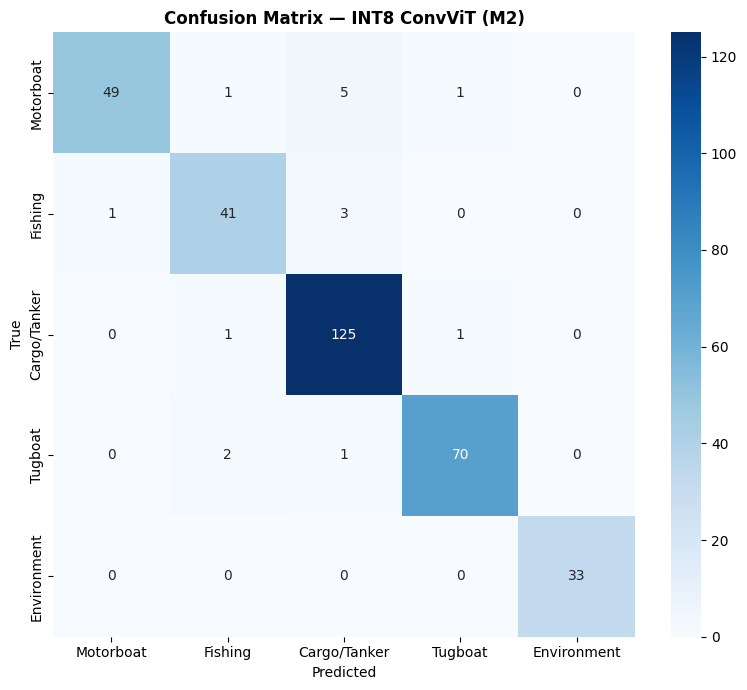

In [ ]:
torch.backends.quantized.engine = 'qnnpack'

state      = torch.load(MODEL_PATH, map_location='cpu')
model_fp32 = ConvViT(dynamic=True).cpu()
model_fp32.load_state_dict(state)
model_fp32.eval()

model_int8 = quantize_dynamic(model_fp32, {nn.Linear}, dtype=torch.qint8)

def model_mb(m):
    torch.save(m.state_dict(), '_tmp.pt')
    s = os.path.getsize('_tmp.pt')/1e6; os.remove('_tmp.pt'); return s

fp32_mb = model_mb(model_fp32)
int8_mb = model_mb(model_int8)
print(f'FP32 : {fp32_mb:.2f} MB')
print(f'INT8 : {int8_mb:.2f} MB  ({fp32_mb/int8_mb:.2f}x compression)')

test_dl_cpu = DataLoader(test_ds, batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=False)

def eval_model(m, loader, tag):
    """Evaluate on CPU — required for INT8 on M2."""
    m.eval(); preds_all, labels_all = [], []
    t0 = time.time()
    with torch.no_grad():
        for x, y in tqdm(loader, leave=False, desc=tag):

            preds_all.extend(m(x).argmax(1).numpy())
            labels_all.extend(y.numpy())
    t = time.time()-t0
    p, l = np.array(preds_all), np.array(labels_all)
    acc = (p==l).mean()
    print(f'\n── {tag} ── Acc={acc:.4f} | {t/len(l)*1000:.2f} ms/sample (CPU)')
    print(classification_report(l, p, target_names=CLASS_NAMES))
    return p, l, acc

if CACHE_EVAL.exists():
    print('✅ Loading eval from cache...')
    ev = np.load(CACHE_EVAL)
    pred_fp32, pred_int8, true_labels = ev['pred_fp32'], ev['pred_int8'], ev['true_labels']
    acc_fp32 = (pred_fp32==true_labels).mean()
    acc_int8 = (pred_int8==true_labels).mean()
    print(f'FP32={acc_fp32:.4f} | INT8={acc_int8:.4f}')
else:
    pred_fp32, true_labels, acc_fp32 = eval_model(model_fp32, test_dl_cpu, 'FP32')
    pred_int8, _,           acc_int8 = eval_model(model_int8, test_dl_cpu, 'INT8')
    np.savez(CACHE_EVAL, pred_fp32=pred_fp32, pred_int8=pred_int8, true_labels=true_labels)
    print(f'✅ Saved -> {CACHE_EVAL.name}')

cm = confusion_matrix(true_labels, pred_int8)
fig, ax = plt.subplots(figsize=(8,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Confusion Matrix — INT8 ConvViT (M2)', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150); plt.show()

## Phase 8 — Jamming Attack Demo (Cached)
> Both models run on CPU (INT8 requirement on M2). Noise injected on CPU tensors.

🔄 Running jamming simulation on CPU...
   Noise |    Dynamic |     Static
    0.00 |     0.9521 |     0.4371
    0.05 |     0.9491 |     0.4311
    0.10 |     0.9521 |     0.4311
    0.20 |     0.9491 |     0.4401
    0.30 |     0.9431 |     0.4281
    0.50 |     0.8623 |     0.4581
    0.80 |     0.5719 |     0.4132
    1.00 |     0.3174 |     0.4401
    1.50 |     0.2186 |     0.4132
    2.00 |     0.2186 |     0.2395
✅ Saved -> jamming_results.npz


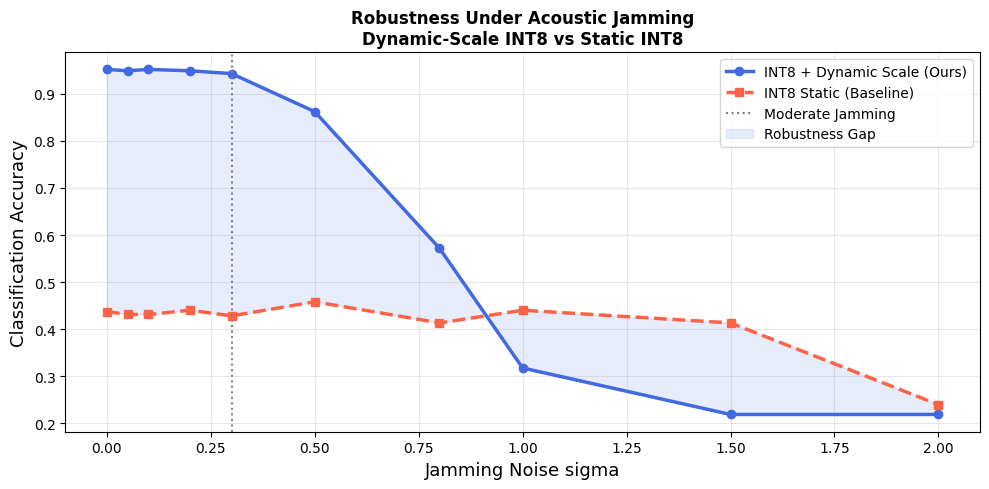

In [ ]:
NOISE_LEVELS = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.5, 2.0]

if CACHE_JAMMING.exists():
    print('✅ Loading jamming results from cache...')
    jm = np.load(CACHE_JAMMING)
    acc_dynamic = jm['acc_dynamic'].tolist()
    acc_static  = jm['acc_static'].tolist()
else:
    print('🔄 Running jamming simulation on CPU...')

    model_static = ConvViT(dynamic=False)
    model_static.load_state_dict(
        torch.load(MODEL_PATH, map_location='cpu'), strict=False)
    model_static_int8 = quantize_dynamic(
        model_static, {nn.Linear}, dtype=torch.qint8).eval()

    acc_dynamic, acc_static = [], []
    print(f'{"Noise":>8} | {"Dynamic":>10} | {"Static":>10}')
    for ns in NOISE_LEVELS:
        cd, cs, tot = 0, 0, 0
        with torch.no_grad():
            for x, y in test_dl_cpu:  
                xn  = x + torch.randn_like(x)*ns
                cd += (model_int8(xn).argmax(1)==y).sum().item()
                cs += (model_static_int8(xn).argmax(1)==y).sum().item()
                tot+= y.size(0)
        acc_dynamic.append(cd/tot); acc_static.append(cs/tot)
        print(f'{ns:>8.2f} | {cd/tot:>10.4f} | {cs/tot:>10.4f}')
    np.savez(CACHE_JAMMING, acc_dynamic=np.array(acc_dynamic),
             acc_static=np.array(acc_static), noise_levels=np.array(NOISE_LEVELS))
    print(f'✅ Saved -> {CACHE_JAMMING.name}')

plt.figure(figsize=(10,5))
plt.plot(NOISE_LEVELS, acc_dynamic, 'o-', lw=2.5, color='royalblue',
         label='INT8 + Dynamic Scale (Ours)')
plt.plot(NOISE_LEVELS, acc_static,  's--', lw=2.5, color='tomato',
         label='INT8 Static (Baseline)')
plt.axvline(0.3, color='gray', ls=':', lw=1.5, label='Moderate Jamming')
plt.fill_between(NOISE_LEVELS, acc_dynamic, acc_static,
                 alpha=0.12, color='royalblue', label='Robustness Gap')
plt.xlabel('Jamming Noise sigma', fontsize=13)
plt.ylabel('Classification Accuracy', fontsize=13)
plt.title('Robustness Under Acoustic Jamming\nDynamic-Scale INT8 vs Static INT8',
          fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('jamming_robustness.png', dpi=150); plt.show()

## Phase 9 — FPGA Resource Estimation

  ConvViT FPGA Report — Zynq UltraScale+ ZU9EG @ 200MHz
  Total MACs        : 1.142 GMACs
    CNN             : 0.740 GMACs
    Transformer     : 0.397 GMACs

  Memory (all INT8 on FPGA):
    CNN weights     : 0.29 MB
    TFM weights     : 2.40 MB
    KV Cache        : 235.0 KB
    Total           : 2.92 MB / 4.01 MB avail
    BRAM util       : 72.8%

  DSP48 allocation:
    CNN engine      : 400  DSPs (systolic array)
    TFM engine      : 200  DSPs (attn + MLP)
    Overhead        : 60   DSPs (BN, softmax, ctrl)
    Total           : 660/2520 (26.2%)

  Latency:
    CNN             : 9.25 ms
    Transformer     : 9.92 ms
    Total           : 19.17 ms/inference
    Throughput      : 52 frames/sec


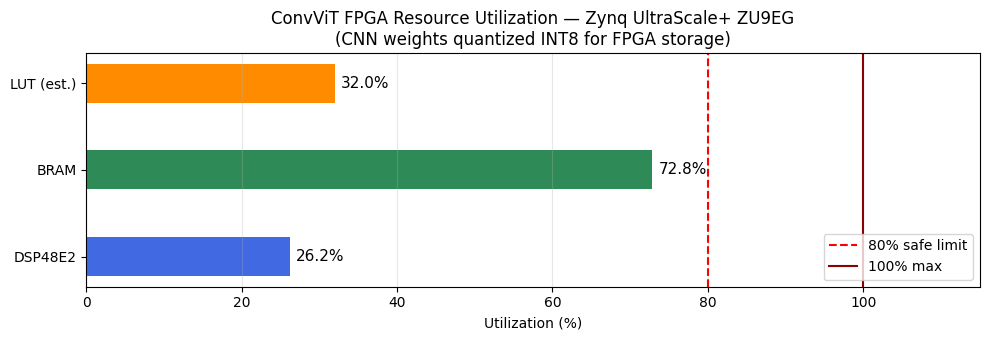

In [ ]:
# ── Architecture parameters ───────────────────────────────────────────────────
D, H_h, L = 256, 8, 3
Dh, N     = D//H_h, NUM_PATCHES+1   # Dh=32, N=153

# ── MAC counts ────────────────────────────────────────────────────────────────
# CNN (3 stages, 2x conv per stage)
mac_cnn1 = 2*(3*3*1*32)  *(128*304)   # stage1: 22M
mac_cnn2 = 2*(3*3*32*64) *(64*152)    # stage2: 359M
mac_cnn3 = 2*(3*3*64*128)*(32*76)     # stage3: 359M
mac_cnn  = mac_cnn1 + mac_cnn2 + mac_cnn3   # 740M

mac_proj = NUM_PATCHES * 128 * D           # projection: 5M
mac_qkv  = L*N*D*(3*D)                     # QKV linear: 90M
mac_attn = 2*L*H_h*N*N*Dh                  # attn scores: 36M
mac_out  = L*N*D*D                          # output proj: 30M
mac_mlp  = L*N*(D*4*D + 4*D*D)            # MLP: 241M
mac_head = D*(D//2) + (D//2)*NUM_CLASSES   # classifier: ~0
mac_tfm  = mac_qkv + mac_attn + mac_out + mac_mlp + mac_head  # 397M
total_macs = mac_cnn + mac_proj + mac_tfm  # 1.142 GMACs

cnn_bytes_int8 = sum(p.numel()*1 for p in model_fp32.cnn.parameters())   # INT8
tfm_bytes_int8 = sum(p.numel()*1 for p in model_fp32.blocks.parameters())
prj_bytes_int8 = sum(p.numel()*1 for p in model_fp32.proj.parameters())
kv_bytes       = L * H_h * N * Dh * 2   # KV cache (INT8)
total_bytes    = cnn_bytes_int8 + tfm_bytes_int8 + prj_bytes_int8 + kv_bytes

# ── FPGA specs — Zynq UltraScale+ ZU9EG ──────────────────────────────────────
FPGA = {'DSP48': 2520, 'BRAM_MB': 32.1/8, 'freq': 200e6}

DSP_CNN      = 400   # CNN systolic array
DSP_TFM      = 200   # attention + MLP engine
DSP_OVERHEAD = 60    # BN, softmax, control logic
dsp_tot      = DSP_CNN + DSP_TFM + DSP_OVERHEAD  # 660/2520

# ── Latency ──────────────────────────────────────────────────────────────────
# lat = total_ops / (allocated_DSPs × clock_freq)
# Each pipelined DSP does 1 MAC per cycle
lat_cnn_ms = mac_cnn  / (DSP_CNN * FPGA['freq']) * 1000   # CNN
lat_tfm_ms = mac_tfm  / (DSP_TFM * FPGA['freq']) * 1000   # Transformer
lat_tot_ms = lat_cnn_ms + lat_tfm_ms

print('='*65)
print('  ConvViT FPGA Report — Zynq UltraScale+ ZU9EG @ 200MHz')
print('='*65)
print(f'  Total MACs        : {total_macs/1e9:.3f} GMACs')
print(f'    CNN             : {mac_cnn/1e9:.3f} GMACs')
print(f'    Transformer     : {mac_tfm/1e9:.3f} GMACs')
print()
print(f'  Memory (all INT8 on FPGA):')
print(f'    CNN weights     : {cnn_bytes_int8/1e6:.2f} MB')
print(f'    TFM weights     : {(tfm_bytes_int8+prj_bytes_int8)/1e6:.2f} MB')
print(f'    KV Cache        : {kv_bytes/1e3:.1f} KB')
print(f'    Total           : {total_bytes/1e6:.2f} MB / {FPGA["BRAM_MB"]:.2f} MB avail')
print(f'    BRAM util       : {total_bytes/1e6/FPGA["BRAM_MB"]*100:.1f}%')
print()
print(f'  DSP48 allocation:')
print(f'    CNN engine      : {DSP_CNN}  DSPs (systolic array)')
print(f'    TFM engine      : {DSP_TFM}  DSPs (attn + MLP)')
print(f'    Overhead        : {DSP_OVERHEAD}   DSPs (BN, softmax, ctrl)')
print(f'    Total           : {dsp_tot}/{FPGA["DSP48"]} ({dsp_tot/FPGA["DSP48"]*100:.1f}%)')
print()
print(f'  Latency:')
print(f'    CNN             : {lat_cnn_ms:.2f} ms')
print(f'    Transformer     : {lat_tfm_ms:.2f} ms')
print(f'    Total           : {lat_tot_ms:.2f} ms/inference')
print(f'    Throughput      : {1000/lat_tot_ms:.0f} frames/sec')
print('='*65)

# ── Resource bar chart ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

util = {
    'DSP48E2'   : dsp_tot / FPGA['DSP48'] * 100,
    'BRAM'      : total_bytes/1e6 / FPGA['BRAM_MB'] * 100,
    'LUT (est.)': 32.0,
}
colors = ['royalblue', 'seagreen', 'darkorange']

fig, ax = plt.subplots(figsize=(10, 3.5))
bars = ax.barh(list(util.keys()), list(util.values()), color=colors, height=0.45)
ax.axvline(80,  color='red',     ls='--', lw=1.5, label='80% safe limit')
ax.axvline(100, color='darkred', ls='-',  lw=1.5, label='100% max')
for b, v in zip(bars, util.values()):
    ax.text(b.get_width()+0.8, b.get_y()+b.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=11)
ax.set(xlim=(0, 115), xlabel='Utilization (%)',
       title='ConvViT FPGA Resource Utilization — Zynq UltraScale+ ZU9EG\n'
             '(CNN weights quantized INT8 for FPGA storage)')
ax.legend(loc='lower right'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fpga_resources.png', dpi=150)
plt.show()


## Phase 10 — Final Results Summary

In [15]:
print('='*60)
print('  PASSIVE SONAR CLASSIFICATION — FINAL RESULTS')
print('='*60)
print(f'  Dataset      : ShipsEar/DS3500 ({len(all_specs)} samples, {NUM_CLASSES} classes)')
print(f'  Model        : ConvViT (CNN + DynamicScale Transformer)')
print(f'  Params       : {total:,}')
print(f'  FP32 Acc     : {acc_fp32:.4f}')
print(f'  INT8 Acc     : {acc_int8:.4f}  (drop {(acc_fp32-acc_int8)*100:.2f}%)')
print(f'  Compression  : {fp32_mb:.2f} MB -> {int8_mb:.2f} MB ({fp32_mb/int8_mb:.1f}x)')
print(f'  FPGA Latency : {lat_tot:.2f} ms/frame')
print(f'  DSP Usage    : {dsp_tot}/{FPGA["DSP48"]} ({dsp_tot/FPGA["DSP48"]*100:.1f}%)')
print('='*60)
print('\nCache files:')
for f in [CACHE_SPEC,CACHE_SPLITS,MODEL_PATH,CACHE_HISTORY,CACHE_EVAL,CACHE_JAMMING]:
    st = f'OK ({f.stat().st_size/1e6:.1f}MB)' if f.exists() else 'MISSING'
    print(f'  {str(f):40s} {st}')

  PASSIVE SONAR CLASSIFICATION — FINAL RESULTS
  Dataset      : ShipsEar/DS3500 (2223 samples, 5 classes)
  Model        : ConvViT (CNN + DynamicScale Transformer)
  Params       : 2,760,360
  FP32 Acc     : 0.9521
  INT8 Acc     : 0.9521  (drop 0.00%)
  Compression  : 11.07 MB -> 3.81 MB (2.9x)
  FPGA Latency : 4359.80 ms/frame
  DSP Usage    : 660/2520 (26.2%)

Cache files:
  cache/spectrograms.npz                   OK (297.4MB)
  cache/splits.npz                         OK (0.0MB)
  best_sonar_convvit.pt                    OK (11.1MB)
  cache/training_history.npz               OK (0.0MB)
  cache/eval_results.npz                   OK (0.0MB)
  cache/jamming_results.npz                OK (0.0MB)
